# Brain Tumour Classification

This is the full script for the proposed few-shot learning approach to brain tumour classification from MRI scans

# Set Up

This involves requirements, imports, and creating a dictionary to hold the dataset items

Key Returns:

*   data/ dataset - dict containing all dataset samples {filepath: (image, label, mask)}


**Imports**

In [ ]:
from PIL import Image
from collections import defaultdict
from google.colab import drive
from pathlib import Path
from scipy.stats import ttest_1samp
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from tqdm import tqdm
import h5py
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
import random
import seaborn as sns
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import zipfile

**Connect to Google Drive**

In [ ]:
# Connect to the Google Drive
drive.mount('/content/drive')

# Zip files containing all of the brain tumour samples
zip_files = [
    '/content/drive/My Drive/1512427/brainTumorDataPublic_1-766.zip',
    '/content/drive/My Drive/1512427/brainTumorDataPublic_1533-2298.zip',
    '/content/drive/My Drive/1512427/brainTumorDataPublic_767-1532.zip',
    '/content/drive/My Drive/1512427/brainTumorDataPublic_2299-3064.zip'
]

# Extracted brain tumour data (if already extracted it before)
# Used to speed up the extraction process
extract_file = "/content/drive/My Drive/1512427/extracted_data"

Mounted at /content/drive


**Download Dataset**

In [ ]:
# If it has already been extracted, read the extracted data from the file
try:
  # Load teh data from the file
  with open("/content/drive/My Drive/ai_models/dataset/data.pkl", "rb") as file:
    dataset = pickle.load(file)
except Exception as e:
  print(e)
  dataset = {}

# Brain tumour types in the dataset in index order (0 = Meningioma, etc)
tumour_types = ["Meningioma", "Glioma", "Pituitary"]

# Extract the zip files
def extract_zip(zip_path, extract_to):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)

# Process the values of the .mat files and store in arrays
def process_mat_file(file_path):
    with h5py.File(file_path, 'r') as mat_data:
        cjdata = mat_data['cjdata']

        # Get the data label (where the range originally is 1-3, so subtract 1 to make range 0-2)
        label = cjdata['label'][0,0] - 1

        # Get the data image as a np array
        image = np.array(cjdata['image'])
        # Normalise image pixel values to between 0 and 255
        image = (image - image.min()) / (image.max() - image.min()) * 255
        image = image.astype(np.uint8)
        # Convert grayscale image to colour
        image = np.repeat(image[..., np.newaxis], 3, -1)

        # Do the same for mask
        mask = np.array(cjdata['tumorMask'])
        mask = (mask - mask.min()) / (mask.max() - mask.min()) * 255
        mask = mask.astype(np.uint8)
        mask = np.repeat(mask[..., np.newaxis], 3, -1)

        return label, image, mask

# If the dataset has not already been extracted into a .pkl file, extract from the zips
if not dataset:
  # Extract the zip files and store in the location mentioned earlier (extract_file), if it hasn't already been extracted
  my_file = Path(extract_file)
  if not my_file.is_dir():
      for zip_file in zip_files:
          extract_zip(zip_file, extract_file)

  # For every .mat file, process the data into the files dictionary
  for file_name in os.listdir(extract_file):
      if file_name.endswith('.mat'):
          file_path = os.path.join(extract_file, file_name)
          try:
              # Extract the label, image and mask from teh .mat file
              label, image, mask = process_mat_file(file_path)
              # Add this information as a tuple to a dictionary with the key as it's file path e.g. 125.mat
              dataset[file_name] = (image, label, mask)
          except OSError as e:
              print(f"Skipping file {file_name} due to error: {e}")

  # Save the data as a .pkl file so only need to extract that instead of all of the zips and mat files again
  data = dataset
  file_path = "/content/drive/My Drive/ai_models/dataset/data.pkl"
  with open(file_path, "wb") as file:
      pickle.dump(data, file)

# Preprocessing

This involves dataset preprocessing and how the data can be accessed and split. This includes: data augmentations, and Gaussian noise.

Key Returns:

*   support_training_transform - transform function to apply to the support training set
*   preprocess_transform - transform for all data images, used to change the image sizes
*   apply_mask(image, mask) - returns the image with the Gaussian noise applied based on the mask (returns a np array)


**Augmentation**

In [ ]:
IMG_SIZE = 256

# Data Augmentation with Random Transformations
support_training_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomRotation(10),  # Minor rotation
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),  # Minor contrast/brightness adjustments
    transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),  # Small affine distortions
    transforms.ToTensor(),
])

**Preprocessing**

In [ ]:
preprocess_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


**Gaussian Noise Function**

In [ ]:
def apply_mask(image, mask):
    # Generate Gaussian noise
    mean = 0
    std_dev = 25
    noise = np.random.normal(mean, std_dev, image.shape)

    # Apply noise only to masked regions (assumes mask is binary)
    noisy_image_array = image + noise * (mask < 1)

    # Clip values to valid range and convert back to uint8
    noisy_image_array = np.clip(noisy_image_array, 0, 255).astype(np.uint8)

    return noisy_image_array


# Dataset

This involves the creation of the dataset class and functions such as splitting the data into train/val/test sets as well as methods to get the support and query sets for an episode from one of these training/validation/testing sets.

Key Returns:

*   split_data(data_dict, val_ratio, test_ratio, seed) - shuffles the data then splits by the input ratio returns dict like the data_dict passed in but of only their respective sets (train_dict, val_dict, test_dict)
*   FewShotDataset (class) - class used to access the data items and view all labels.
  *   get_episode(n_way, k_shot, q_queries) - takes in the number of ways, shots, and queries and tehn splits appropriately, returning the support and query sets

**Define dataset split function**

In [ ]:
def split_data(data_dict, val_ratio=0.1, test_ratio=0.1, seed=42):
    # Create the seed
    random.seed(seed)

    # Organize data by label
    label_to_items = defaultdict(list)
    for fname, (img, label, mask) in data_dict.items():
        label_to_items[label].append((fname, img, label, mask))

    train_dict = {}
    val_dict = {}
    test_dict = {}

    # Shuffle the data and keep the images and respective labels bound together
    for label, items in label_to_items.items():
        random.shuffle(items)
        total_len = len(items)

        # Split data into train, validation, and test sets
        val_len = int(total_len * val_ratio)
        test_len = int(total_len * test_ratio)

        # Ensure there are enough samples for all splits
        train_len = total_len - val_len - test_len

        train_items = items[:train_len]
        val_items = items[train_len:train_len+val_len]
        test_items = items[train_len+val_len:]

        # Add these items to their respective dicts
        train_dict.update({fname: (img, label, mask) for fname, img, label, mask in train_items})
        val_dict.update({fname: (img, label, mask) for fname, img, label, mask in val_items})
        test_dict.update({fname: (img, label, mask) for fname, img, label, mask in test_items})

    return train_dict, val_dict, test_dict


**Define Dataset Class**

In [ ]:
class FewShotDataset:
    # Dataset class
    def __init__(self, data_dict):
        self.label_to_items = defaultdict(list)
        for _, (img, label, mask) in data_dict.items():
            self.label_to_items[label].append((img, label, mask))
        # Define the labels
        self.labels = list(self.label_to_items.keys())

    def get_episode(self, n_way, k_shot, q_queries):
        # Get the support and query sets for the episode
        selected_classes = random.sample(self.labels, n_way)
        support = []
        query = []

        # Pick x random images for support and y random for query
        for label in selected_classes:
            items = self.label_to_items[label]
            if len(items) < k_shot + q_queries:
                raise ValueError(f"Not enough examples for class {label}")
            sampled = random.sample(items, k_shot + q_queries)
            support += [(img, label, mask) for img, _, mask in sampled[:k_shot]]
            query += [(img, label, mask) for img, _, mask in sampled[k_shot:]]


        return support, query


#Build the Model

This involves the creation of the prototypical network and the other functions involved such as the loss function

Key Returns:

*   device - used for saving the training of the model and different parameters to speed up execution
*   model - the object of the ProtoNet class


**Loss Function**

In [ ]:
# Focal loss implementation
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.gamma = gamma

    def forward(self, scores, labels):
        # Use cross entropy loss
        ce_loss = F.cross_entropy(scores, labels, reduction="none", label_smoothing=0.1)
        # The probablility of the correct class
        pt = torch.exp(-ce_loss)
        # Calculate the focal loss for all scores
        focal_loss = (1 - pt) ** self.gamma * ce_loss
        return focal_loss.mean()


**ProtoNet Class**

In [ ]:
# Prototypical network class
class ProtoNet(nn.Module):
    def __init__(self, backbone: nn.Module, feature_dim=512, dropout_prob=0.5):
        super(ProtoNet, self).__init__()
        # Set backbone to the pretrained network and implement some fine-tuning
        self.backbone = backbone
        self.projection_head = nn.Sequential(
            nn.Linear(feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(p=dropout_prob),
            nn.Linear(256, 128)
        )

    def forward(self, support_images, support_labels, query_images):
        # Extract the features
        z_support = self.projection_head(self.backbone(support_images))
        z_query = self.projection_head(self.backbone(query_images))

        # L2 Normalisation for stability
        z_support = F.normalize(z_support, p=2, dim=1)
        z_query = F.normalize(z_query, p=2, dim=1)

        # Compute the Prototypes
        n_way = len(support_labels.unique())
        z_proto = torch.cat([
            z_support[support_labels == label].mean(0, keepdim=True)
            for label in range(n_way)
        ])

        # Compute the Squared Euclidean Distances
        dists = torch.cdist(z_query, z_proto, p=2) ** 2
        # Convert distances to similarity scores
        scores = -dists
        return scores

# Load and Modify ResNet34
pretrained_model = models.resnet34(pretrained=True)
# Remove the final fully classified layer to change to the new target domain
pretrained_model.fc = nn.Identity()
# Allow for different image sizes to what it was trained on
pretrained_model.avgpool = nn.AdaptiveAvgPool2d(1)

# Create a device and model object
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = ProtoNet(pretrained_model).to(device)

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth
100%|██████████| 83.3M/83.3M [00:00<00:00, 161MB/s]


# Training

This involves creating the dataset objects, and defining the evaluation function then training and evaluating the performance of the model

Key Returns:

*   train_dataset - object of FewShotDataset for the training set
*   val_dataset - object of FewShotDataset for the validation set
*   test_dataset - object of FewShotDataset for the testing set
*   evaluate_protonet(model, dataset, device, n_way, k_shot, q_queries, num_episodes=20) - function to evaluate the performance of the model, input the validation dataset and the current version of the model and it will return the validation accuracy and loss
*   train_protonet(model, train_dataset, val_dataset, device, epochs=30, episodes_per_epoch=100, val_episodes=20, n_way=3, k_shot=5, q_queries=15,
 lr=0.0001, weight_decay=1e-3, patience=5, mask_probability=0.75) - used for training the model with all the different hyperparameters



**Create the Dataset Class**

In [ ]:
# Split the dataset and pass teh resulting splits into their appropriate FewShotDataset objects
train_dict, val_dict, test_dict = split_data(dataset, val_ratio=0.2, test_ratio=0.1)
train_dataset = FewShotDataset(train_dict)
val_dataset = FewShotDataset(val_dict)
test_dataset = FewShotDataset(test_dict)

**View the dataset split**

In [ ]:
# Print how many items in training, validation and testing
print(len(train_dict.keys()))
print(len(val_dict.keys()))
print(len(test_dict.keys()))

# Compare how many of each class are in each dataset (meningioma, glioma, and pituitary)
dicts = [train_dict, val_dict, test_dict]
dicts_string = ["Train Set", "Val Set", "Test Set"]
# For each set, count how many of each label are in the dict
for i in range(len(dicts)):
    d = dicts[i]
    count = [0,0,0]
    for v in list(d.values()):
        count[int(v[1])] += 1
    print(f"{dicts_string[i]}: {count[0]}, {count[1]}, {count[2]}")

2146
612
305
Train Set: 496, 999, 651
Val Set: 141, 285, 186
Test Set: 70, 142, 93


**Evaluate Performance Function**

In [ ]:
def evaluate_protonet(model, dataset, device, n_way, k_shot, q_queries, num_episodes=20):
    # Set the model to evaluation mode
    model.eval()
    losses = []
    accuracies = []
    criterion = FocalLoss(gamma=2.0)

    # Don't calculate gradients during evaluation
    with torch.no_grad():
        # Episodic training
        for _ in range(num_episodes):
            # Get the support and query set for the episode
            support, query = dataset.get_episode(n_way, k_shot, q_queries)

            # Process support images/labels and query images/labels
            support_images = torch.stack([preprocess_transform(img).to(device) for img, _, _ in support])
            support_labels = torch.tensor([label for _, label, _ in support]).to(device)
            query_images = torch.stack([preprocess_transform(img).to(device) for img, _, _ in query])
            query_labels = torch.tensor([label for _, label, _ in query]).to(device)

            # Map the original labels to a 0-2 range
            unique_labels = torch.unique(support_labels)
            label_map = {label.item(): idx for idx, label in enumerate(unique_labels)}
            support_labels = torch.tensor([label_map[label.item()] for label in support_labels]).to(device)
            query_labels = torch.tensor([label_map[label.item()] for label in query_labels]).to(device)

            # Forward pass
            scores = model(support_images, support_labels, query_images)

            # Compute the loss and accuracy
            loss = criterion(scores, query_labels)
            acc = (scores.argmax(dim=1) == query_labels).float().mean().item()

            # Append to the arrays to calculate an average for all episodes
            losses.append(loss.item())
            accuracies.append(acc)

    # Calculate the average loss and accuracy over all episodes
    val_loss = sum(losses) / len(losses)
    val_acc = sum(accuracies) / len(accuracies)

    return val_loss, val_acc


**Train the model**

In [ ]:
# Function for episodic training of the model
def train_protonet(model, train_dataset, val_dataset, device,
                   epochs=30, episodes_per_epoch=100, val_episodes=20,
                   n_way=3, k_shot=5, q_queries=15,
                   lr=0.0001, weight_decay=1e-3, patience=5, mask_probability=0.75):

    # Define the optimiser, learning rate scheduler and focal loss
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.3, patience=3)
    criterion = FocalLoss(gamma=2.0)

    # Use validation loss for early stopping
    best_val_loss = float('inf')
    patience_counter = 0

    # Train the model
    for epoch in range(epochs):
        # Set the model into train
        model.train()
        episode_losses = []
        episode_accuracies = []

        # Episodic training
        for _ in range(episodes_per_epoch):
            # Get the support and query sets for the episode
            support, query = train_dataset.get_episode(n_way, k_shot, q_queries)

            # Apply the appropriate transforms for the support set, and apply the mask randomly
            support_images = torch.stack([
                support_training_transform(
                    apply_mask(img, mask) if random.random() < mask_probability else img
                ).to(device)
                for img, _, mask in support
            ])
            # Extract the support labels
            support_labels = torch.tensor([label for _, label, _ in support]).to(device)

            # Preprocess the query images
            query_images = torch.stack([
                preprocess_transform(img).to(device)
                for img, _, _ in query
            ])
            # Extract the query labels
            query_labels = torch.tensor([label for _, label, _ in query]).to(device)

            # Map the original labels to 0-2
            unique_labels = torch.unique(support_labels)
            label_map = {label.item(): idx for idx, label in enumerate(unique_labels)}
            support_labels = torch.tensor([label_map[label.item()] for label in support_labels]).to(device)
            query_labels = torch.tensor([label_map[label.item()] for label in query_labels]).to(device)

            # Reset the gradient for backpropagation
            optimizer.zero_grad()
            # Train the model
            scores = model(support_images, support_labels, query_images)
            # Perform backpropagation
            loss = criterion(scores, query_labels)
            loss.backward()
            optimizer.step()

            # Calculate the training accuracy and loss for the episode
            acc = (scores.argmax(dim=1) == query_labels).float().mean().item()
            episode_losses.append(loss.item())
            episode_accuracies.append(acc)

        # Calculate the average training loss and accuracy for the epoch
        avg_loss = sum(episode_losses) / len(episode_losses)
        avg_acc = sum(episode_accuracies) / len(episode_accuracies)

        # Validation
        val_loss, val_acc = evaluate_protonet(model, val_dataset, device, n_way, k_shot, q_queries, val_episodes)
        # Adjust the learning rate appropriately
        scheduler.step(val_loss)

        # Output the training and validation metrics
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {avg_loss:.4f} | Train Acc: {avg_acc:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

        # Early Stopping
        if val_loss < best_val_loss:
            # If new best model, reset the patience
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), "best_model.pth")
        else:
            patience_counter += 1

        # Escape for early stopping and avoiding overfitting
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Load the best performing version of the model
    print("Training finished. Loading best model...")
    model.load_state_dict(torch.load("best_model.pth"))
    return model

# Train the model
model = train_protonet(model, train_dataset, val_dataset, device, patience=15, epochs=100, lr=0.00005, episodes_per_epoch=100, q_queries=15)

Epoch 1/100 | Train Loss: 0.1939 | Train Acc: 0.8564 | Val Loss: 0.0873 | Val Acc: 0.9522
Epoch 2/100 | Train Loss: 0.0472 | Train Acc: 0.9922 | Val Loss: 0.0971 | Val Acc: 0.9533
Epoch 3/100 | Train Loss: 0.0377 | Train Acc: 0.9949 | Val Loss: 0.0684 | Val Acc: 0.9633
Epoch 4/100 | Train Loss: 0.0292 | Train Acc: 0.9984 | Val Loss: 0.0742 | Val Acc: 0.9678
Epoch 5/100 | Train Loss: 0.0265 | Train Acc: 0.9993 | Val Loss: 0.0608 | Val Acc: 0.9778
Epoch 6/100 | Train Loss: 0.0247 | Train Acc: 1.0000 | Val Loss: 0.0724 | Val Acc: 0.9700
Epoch 7/100 | Train Loss: 0.0235 | Train Acc: 1.0000 | Val Loss: 0.0978 | Val Acc: 0.9511
Epoch 8/100 | Train Loss: 0.0230 | Train Acc: 1.0000 | Val Loss: 0.0562 | Val Acc: 0.9756
Epoch 9/100 | Train Loss: 0.0402 | Train Acc: 0.9876 | Val Loss: 0.1219 | Val Acc: 0.9389
Epoch 10/100 | Train Loss: 0.0290 | Train Acc: 0.9958 | Val Loss: 0.0678 | Val Acc: 0.9700
Epoch 11/100 | Train Loss: 0.0271 | Train Acc: 0.9971 | Val Loss: 0.0624 | Val Acc: 0.9756
Epoch 12

# Testing

This involves testing the performance of the trained model and outputting the results visually in the forms of classification reports and confusion matrices as well as calculating the statistical significatnce of the model

Key Returns:

*   get_predictions_for_confusion_matrix(model, dataset, device, n_way=5, k_shot=5, q_queries=10, episodes=20) - function for returning the true and predicted labels from the test dataset, used to compute the classification report and confusion matrix
*   y_true - the true labels
*   y_pred - the predicted labels
*   cm - the confusion matrix



In [ ]:
# Get predictions and true labels from the testing dataset
def get_predictions_for_confusion_matrix(model, dataset, device, n_way=3, k_shot=5, q_queries=15, episodes=20):
    # Set model into evaluation mode
    model.eval()
    all_preds = []
    all_labels = []
    episode_accuracies = []

    # No gradient calculation
    with torch.no_grad():
        # Episodic testing
        for _ in range(episodes):
            # Get the support and query sets for the episode
            support, query = dataset.get_episode(n_way=n_way, k_shot=k_shot, q_queries=q_queries)

            # Get the support and query images/labels
            support_images = torch.stack([preprocess_transform(img).to(device) for img, _, _ in support])
            support_labels = torch.tensor([label for _, label, _ in support]).to(device)
            query_images = torch.stack([preprocess_transform(img).to(device) for img, _, _ in query])
            query_labels = torch.tensor([label for _, label, _ in query]).to(device)

            # Map the original labels to 0-2
            unique_labels = torch.unique(support_labels)
            label_map = {label.item(): idx for idx, label in enumerate(unique_labels)}
            support_labels = torch.tensor([label_map[l.item()] for l in support_labels]).to(device)
            query_labels = torch.tensor([label_map[l.item()] for l in query_labels]).to(device)

            # Make predictions on the test dataset using the trained model
            scores = model(support_images, support_labels, query_images)
            preds = torch.argmax(scores, dim=1)

            # Add the true and predicted labels to arrays
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(query_labels.cpu().tolist())

            # Add the episode accuracy
            ep_acc = accuracy_score(query_labels.cpu(), preds.cpu())
            episode_accuracies.append(ep_acc)

    return all_labels, all_preds, episode_accuracies


**Get the true and predicted labels, and episodic accuracies**

In [ ]:
# Get the true labels, predicted labels, and episode accuruacies
y_true, y_pred, episode_accuracies = get_predictions_for_confusion_matrix(model, test_dataset, device, n_way=3, k_shot=5, q_queries=15)

**Classification Report**

In [ ]:
# Ouptut the classification report with 4dp
print("Classification Report:\n", classification_report(y_true, y_pred, digits=4))

Classification Report:
               precision    recall  f1-score   support

           0     0.9695    0.9533    0.9613       300
           1     0.9554    1.0000    0.9772       300
           2     1.0000    0.9700    0.9848       300

    accuracy                         0.9744       900
   macro avg     0.9750    0.9744    0.9744       900
weighted avg     0.9750    0.9744    0.9744       900



**Confusion Matrix**

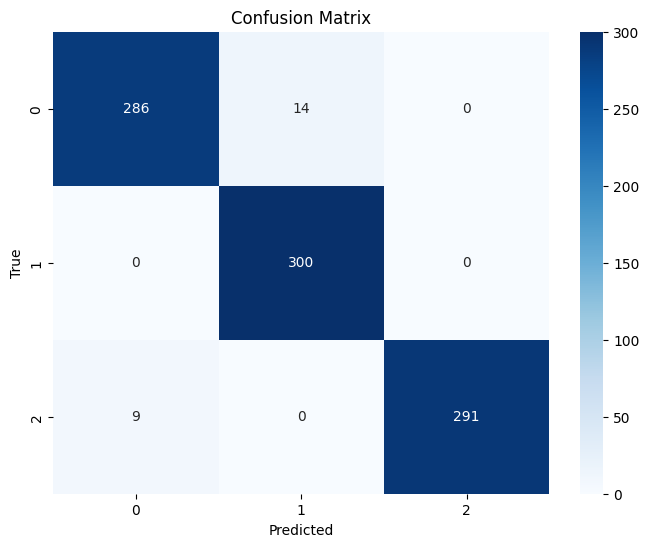

In [ ]:
# Create the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot the confusion matrix with matplotlib and seaborn heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(cm.shape[0]), yticklabels=range(cm.shape[0]))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

**Statistical Significance Testing**

In [ ]:
# Calculate the statistical significance of the episodic accuracies
t_stat, p_value = ttest_1samp(episode_accuracies, 1/3)
print(f"T-statistic: {t_stat:.4f}, P-value: {p_value:.4e}")

# Calculate the standard deviation of the accuracies
std_dev = np.std(episode_accuracies, ddof=1)  # Sample standard deviation
print(f"Standard Deviation: {std_dev:.4f}")

T-statistic: 171.1319, P-value: 9.3148e-32
Standard Deviation: 0.0169


# Save and Download Model

This involves saving the training of the model so that it can be used later without having to train the whole model again

**Save Model**

In [ ]:
torch.save(model, "/content/drive/My Drive/ai_models/models/final.pth")

**Download Model**

In [ ]:
model_path = "/content/drive/My Drive/ai_models/models/final.pth"
#model = torch.load(model_path, weights_only=False)
model = torch.load(model_path, weights_only=False, map_location=torch.device('cpu'))  # Explicitly allow loading full model